Environment

In [ ]:
import importlib

import matplotlib.pyplot as plt
import numpy as np

import bsrl_fit
from bsrl_fit import expected_counts, simulate_profile
from bsrl_fit.model import S_N, S_SIGMA, T_MAX, T_MIN

importlib.reload(bsrl_fit)

### 1. Simulate Poisson-sampled photon counts

- **Model = Expected counts** (lam): the deterministic prediction of the model -> for each time bin, how many photons there would be on average if the experiment was repeated infinitely many times. It's 	
- **Data = Sampled counts** (counts): one realisation of the noisy experiment -> for each bin, an integer draw from Poisson ~ what a real BSRL detector record on a single acquisition. Random, integer, and scattering around the expected line with spread 

Modelisation:
- Main peak: Many particles are counted, so the Poisson distribution is well approximated by a Gaussian. The scatter is larger in absolute terms (because μ is larger), but the Gaussian approximation is accurate.
- Tails: Very few particles are counted. The scatter is smaller in absolute terms, but the data are discrete and asymmetric -> Gaussian approximations break at low counts, and using a Poisson likelihood gives more accurate parameter estimates and uncertainty quantification.

In [2]:
t_grid = np.arange(0, 50, 0.05)
theta = [1e5, 0.3, 1e-2, 1e-3, 5.0, 10.0]  # N-main, sigma, f_sat, f_ghost, t0, background
rng = np.random.default_rng(42)

lam = expected_counts(theta, t_grid)
counts = simulate_profile(theta, t_grid, rng)

- Main peak: N_main * dt / (σ√(2π)) ≈ 1e5 * 0.05 / (0.3 * 2.5) ≈ 6600 counts at peak.
- Satellite: f_sat = 1e-2 → peak ≈ 66 counts.
- Ghost: f_ghost = 1e-3 → peak ≈ 6.6 counts.
- Background: 10 photons/ns * 0.05 ns = 0.5 counts/bin.

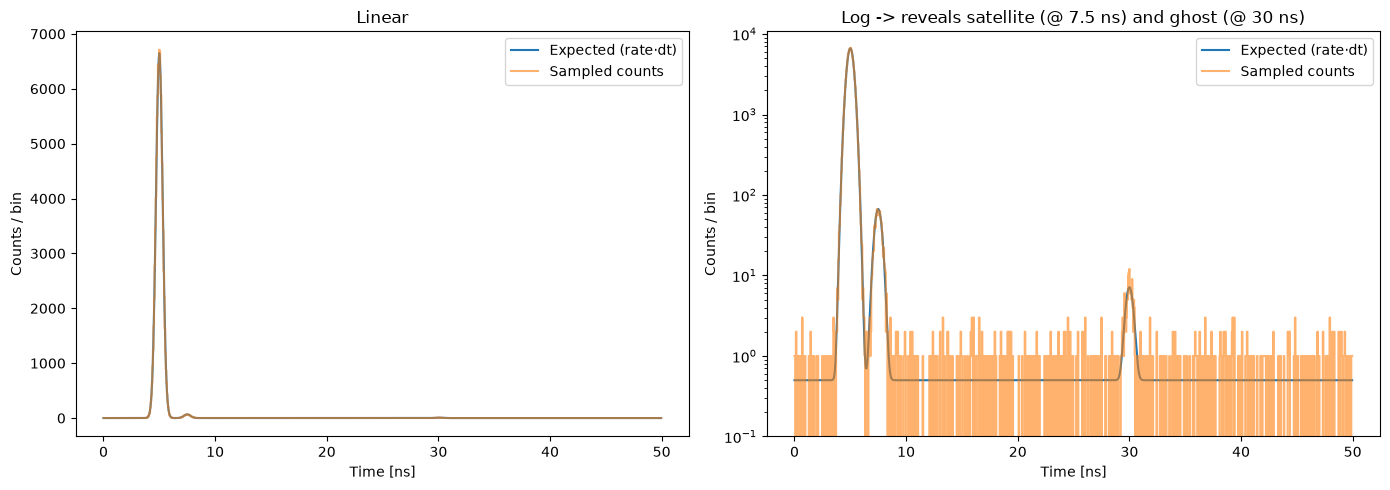

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax in (ax1, ax2):
    ax.plot(t_grid, lam, label="Expected (rate·dt)", lw=1.5)
    ax.plot(t_grid, counts, drawstyle="steps-mid", label="Sampled counts", alpha=0.6)
    ax.set_xlabel("Time [ns]")
    ax.set_ylabel("Counts / bin")
    ax.legend()

ax2.set_yscale("log")
ax2.set_ylim(0.1, None)
ax1.set_title("Linear")
ax2.set_title("Log -> reveals satellite (@ 7.5 ns) and ghost (@ 30 ns)")
plt.tight_layout()

Observations:
- Three peaks in the log plot, at 5, 7.5, and 30 ns.
- The random fluctuations are larger where the counts are larger =  regions with many counts (the peak) show a larger absolute spread, while regions with few counts (the tails) show a smaller absolute spread, even though their relative uncertainty is larger. (Poisson σ = √μ). A bin with μ=6600 scatters by ~81 (~1%); a bin with μ=0.5 scatters by ~0.7 (200%). -> at high counts, the Poisson distribution is approximately Gaussian
- Background level is ~0.5 counts/bin between the peaks, most bins showing 0 or 1.

### 2. Prior calibration

I chose weakly informative priors: the scale is ~10× my expected value: non-negligible density at the truth, decaying at physically unreasonable values.

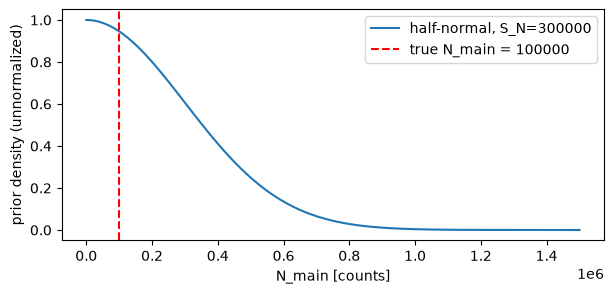

In [ ]:
# plot the half-normal on N_main
N_true = theta[0]
N_grid = np.linspace(0, 5 * S_N, 500)
poisson_df_N = np.exp(-(N_grid**2) / (2 * S_N**2))  # unnormalized, proportional to prior

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(N_grid, poisson_df_N, label=f"half-normal, S_N={S_N:g}")
ax.axvline(N_true, color="red", linestyle="--", label=f"true N_main = {N_true:g}")
ax.set_xlabel("N_main [counts]")
ax.set_ylabel("prior density (unnormalized)")
ax.legend()
plt.show()

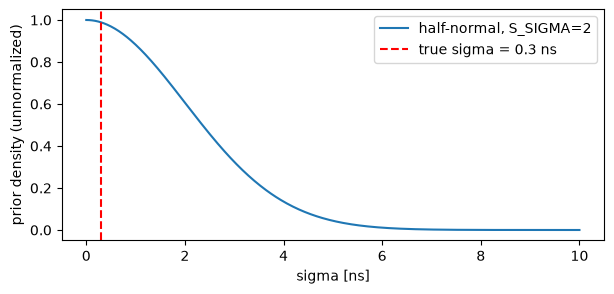

In [5]:
# plot the half-normal on sigma
sigma_true = theta[1]
s_grid = np.linspace(0, 5 * S_SIGMA, 500)
pdf_s = np.exp(-(s_grid**2) / (2 * S_SIGMA**2))

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(s_grid, pdf_s, label=f"half-normal, S_SIGMA={S_SIGMA:g}")
ax.axvline(sigma_true, color="red", linestyle="--", label=f"true sigma = {sigma_true} ns")
ax.set_xlabel("sigma [ns]")
ax.set_ylabel("prior density (unnormalized)")
ax.legend()
plt.show()

Observations: at the true value, the prior density is still ~1 (peak), so the prior is not pulling the posterior away from the truth. At 3× the scale, density has dropped enough to discourage the sampler from wandering too far.

### 3. Prior predictive check
Draw θ from the prior 50 times and plot the resulting rate curves. Each curve is a bunch profile the prior considers plausible before seeing any data. If most curves look like reasonable single-bunch structures with satellites/ghosts of the expected scale, priors are well-calibrated

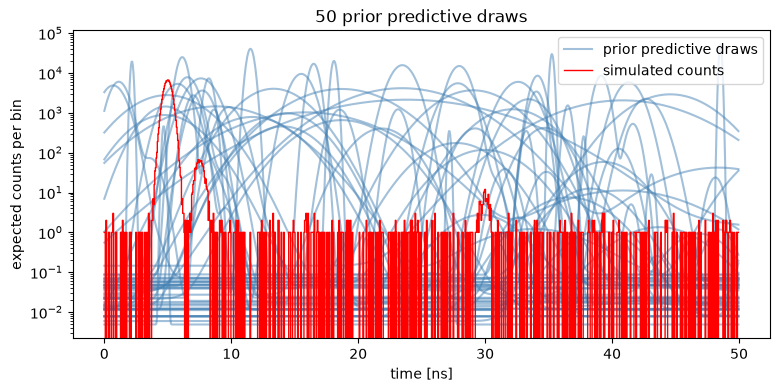

In [ ]:
rng = np.random.default_rng(42)
n_draws = 50

fig, ax = plt.subplots(figsize=(9, 4))
for _ in range(n_draws):
    # 1. draw each parameter from its prior
    theta = (
        np.abs(rng.normal(0, S_N)),  # N_main
        np.abs(rng.normal(0, S_SIGMA)),  # sigma
        10 ** rng.uniform(-6, -1),  # f_sat
        10 ** rng.uniform(-6, -1),  # f_ghost
        rng.uniform(T_MIN, T_MAX),  # t0
        np.abs(rng.normal(scale=1)),  # background
    )
    # 2. compute the noise-free rate
    mu = expected_counts(theta, t_grid)
    # 3. plot with low alpha so overlap is visible
    ax.plot(
        t_grid, mu, color="steelblue", alpha=0.5, label="prior predictive draws" if _ == 0 else None
    )

ax.plot(t_grid, counts, drawstyle="steps-mid", color="red", lw=1, label="simulated counts")
ax.set_xlabel("time [ns]")
ax.set_ylabel("expected counts per bin")
ax.set_yscale("log")  # bunch profiles span many orders of magnitude — log is essential
ax.set_title(f"{n_draws} prior predictive draws")
plt.legend()
plt.show()

Observations:
- Range of amplitudes spans ~10⁻² to ~10⁵ -> reasonable
- Some curves show a clear peak
- The simulated data (red) is contained within the envelope of prior draws

- The prior predictive check revealed that my initial S_SIGMA = 10 allowed bunch widths comparable to the analysis window (50 ns), which is unphysical for LHC bunches (~1 ns).